# Employee Turnover Analytics
### Machine Learning Course-End Project — Portobello Tech

---

**Objective:** Predict employee turnover and suggest retention strategies using ML techniques.

**Dataset:** HR data with 14,999 employee records including satisfaction levels, evaluations, project counts, working hours, tenure, salary, and department.

**Steps:**
1. Data Quality Checks
2. Exploratory Data Analysis (EDA)
3. K-Means Clustering
4. Class Imbalance Handling (SMOTE)
5. 5-Fold Cross-Validation Model Training
6. Best Model Identification (ROC/AUC + Confusion Matrix)
7. Retention Strategies

---


#### Perform the following steps:

1. Perform data quality checks by checking for missing values, if any.
2. Understand what factors contributed most to employee turnover at EDA.
    1. Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
    2. Draw the distribution plot of:
        - Employee Satisfaction (use column satisfaction_level)
        - Employee Evaluation (use column last_evaluation)
        - Employee Average Monthly Hours (use column average_montly_hours)
    3. Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.
3. Perform clustering of employees who left based on their satisfaction and evaluation.
    1. Choose columns satisfaction_level, last_evaluation, and left.
    2. Do K-means clustering of employees who left the company into 3 clusters?
    3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.
4. Handle the left Class Imbalance using the SMOTE technique.
    1. Pre-process the data by converting categorical columns to numerical columns by:
        - Separating categorical variables and numeric variables
        - Applying get_dummies() to the categorical variables
        - Combining categorical variables and numeric variables
    2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
    3. Upsample the train dataset using the SMOTE technique from the imblearn module.
5. Perform 5-fold cross-validation model training and evaluate performance.
    1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
    2. Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
    3. Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.
6. Identify the best model and justify the evaluation metrics used.
    1. Find the ROC/AUC for each model and plot the ROC curve.
    2. Find the confusion matrix for each of the models.
    3. Explain which metric needs to be used from the confusion matrix: Recall or Precision?
7. Suggest various retention strategies for targeted employees.
    1. Using the best model, predict the probability of employee turnover in the test data.
    2. Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
        - Safe Zone (Green) (Score < 20%)
        - Low-Risk Zone (Yellow) (20% < Score < 60%)
        - Medium-Risk Zone (Orange) (60% < Score < 90%)
        - High-Risk Zone (Red) (Score > 90%).

##  Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


---
## Load Dataset

In [13]:
df = pd.read_csv("HR_comma_sep.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: (14999, 10)

Column names: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


---
## Step 1: Data Quality Checks

Checking for missing values, data types, and class distribution before any modeling.


In [14]:
# Data types
print("── Data Types ──")
print(df.dtypes)

── Data Types ──
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object


In [15]:
# Missing values
print("── Missing Values ──")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

── Missing Values ──
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Total missing values: 0


In [16]:
# Basic statistics
print("── Descriptive Statistics ──")
df.describe()

── Descriptive Statistics ──


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


── Class Distribution (left) ──
left
0    11428
1     3571
Name: count, dtype: int64

Turnover Rate: 23.8%


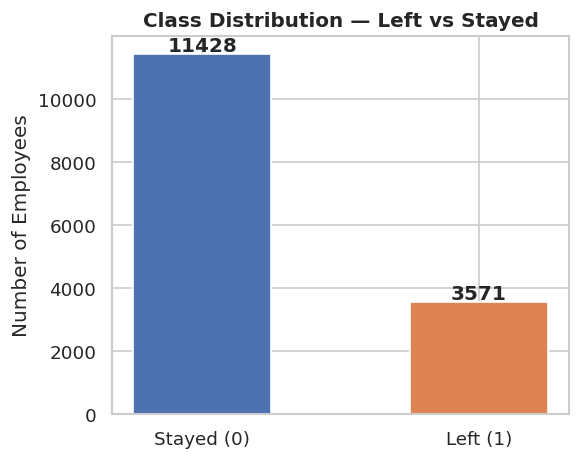

In [17]:
# Class distribution
print("── Class Distribution (left) ──")
counts = df['left'].value_counts()
print(counts)
print(f"\nTurnover Rate: {df['left'].mean()*100:.1f}%")

# Visualize class imbalance
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Stayed (0)', 'Left (1)'], counts.values, color=['#4C72B0', '#DD8452'],
       edgecolor='white', width=0.5)
ax.set_title('Class Distribution — Left vs Stayed', fontweight='bold')
ax.set_ylabel('Number of Employees')
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

###  Data Quality Findings

- **No missing values** found across all 14,999 rows and 10 columns ✅
- The dataset is **clean and ready** for analysis
- **Class imbalance detected:** ~76% stayed, ~24% left — will be addressed with SMOTE in Step 4
- Data types are appropriate — numerical features are float/int, categorical are object


---
##  Step 2: Exploratory Data Analysis (EDA)

Understanding the factors that contribute most to employee turnover.


### 2a. Correlation Heatmap

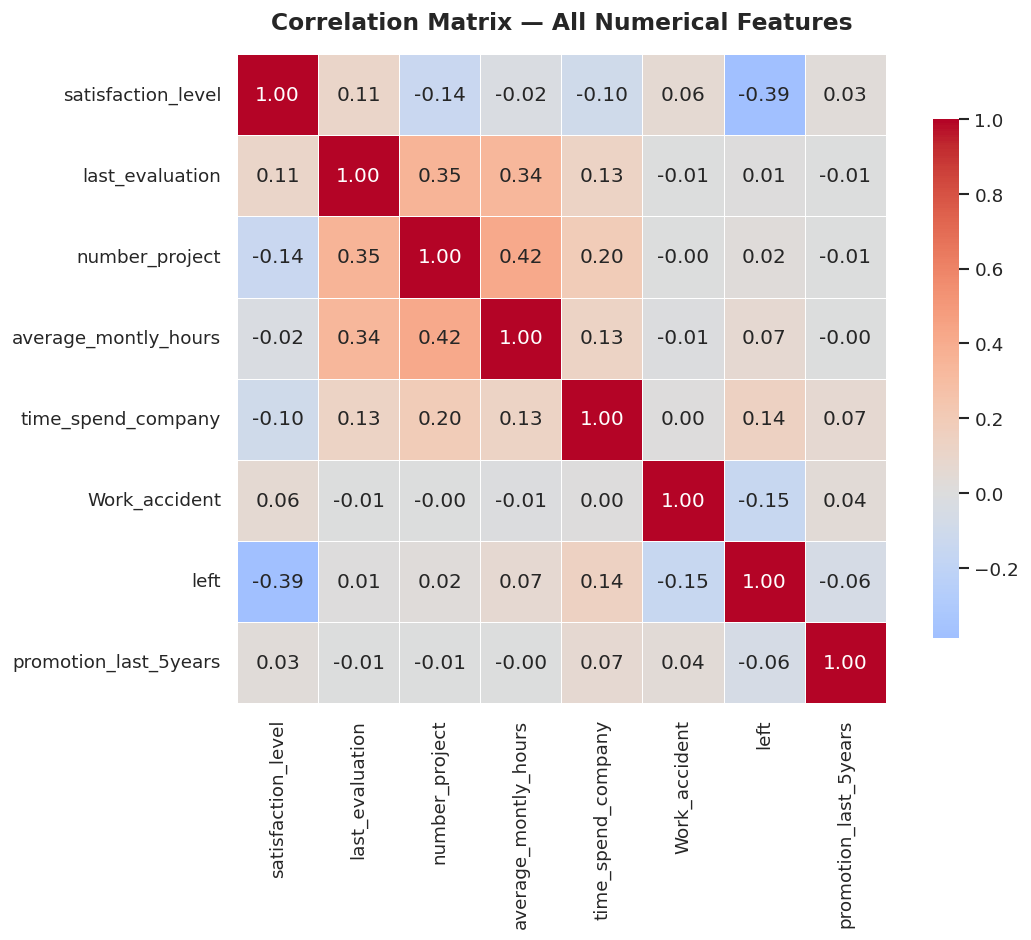


Top correlations with 'left':
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


In [32]:
# Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — All Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop correlations with 'left':")
print(corr_matrix['left'].sort_values(ascending=False))

####  Heatmap Insights
- **`satisfaction_level`** has the strongest negative correlation with `left` (-0.39) — unhappy employees leave most
- **`time_spend_company`** has a moderate positive correlation (+0.14) — longer-tenured employees are also at risk
- **`average_monthly_hours`** and **`number_project`** show mild positive correlation with turnover
- **`Work_accident`** and **`promotion_last_5years`** are negatively correlated — employees with accidents or promotions tend to stay


### 2b. Distribution Plots

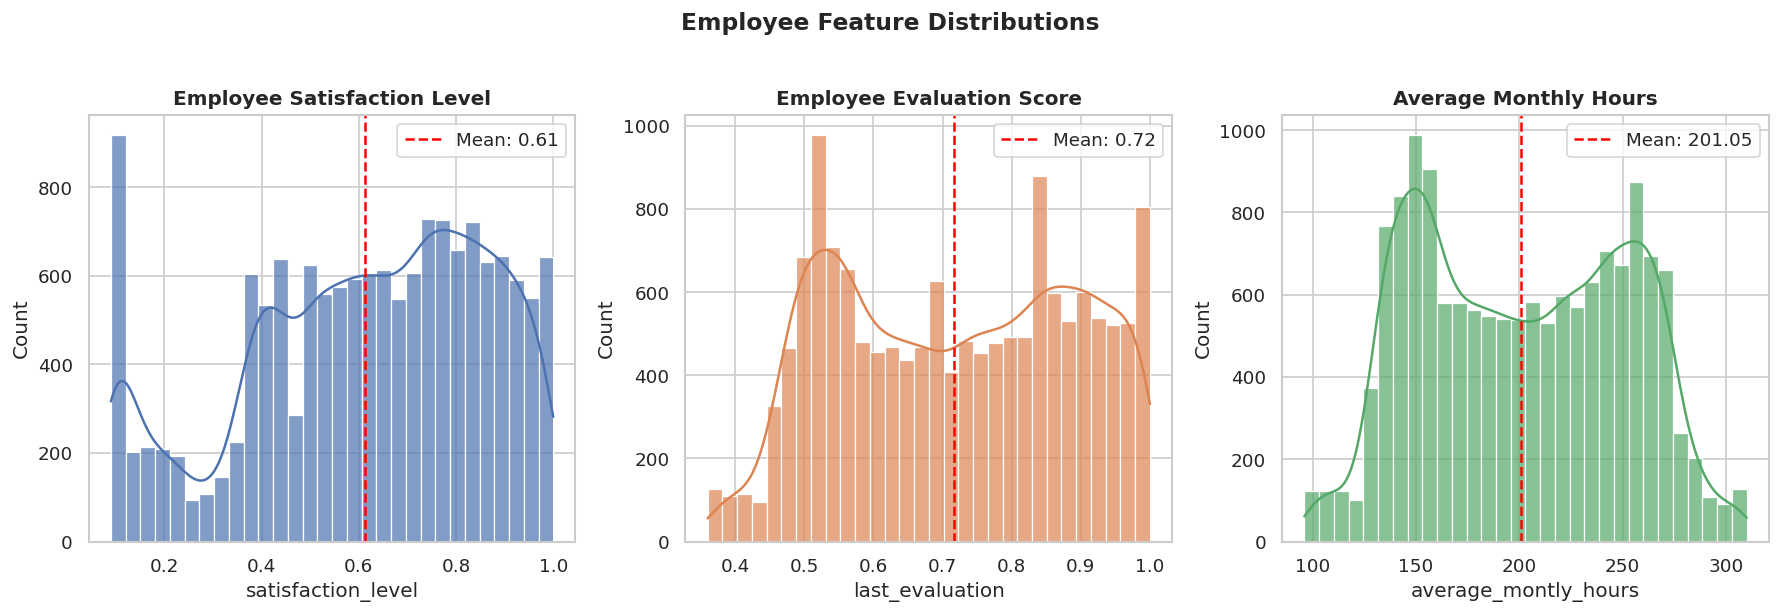

In [33]:
# Draw the distribution plot of: Employee Satisfaction (use column satisfaction_level) , Employee Evaluation (use column last_evaluation) , Employee Average Monthly Hours (use column average_montly_hours)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Employee Feature Distributions', fontsize=14, fontweight='bold', y=1.02)

plot_configs = [
    ('satisfaction_level', 'Employee Satisfaction Level', '#4C72B0'),
    ('last_evaluation',    'Employee Evaluation Score',   '#DD8452'),
    ('average_montly_hours','Average Monthly Hours',      '#55A868'),
]

for ax, (col, title, color) in zip(axes, plot_configs):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color=color, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

####  Distribution Insights
- **Satisfaction Level:** Bimodal distribution — large cluster of very unhappy employees (< 0.2) alongside a majority who are satisfied. The low-satisfaction cluster is a major turnover risk.
- **Evaluation Score:** Mostly uniform with a slight right skew — a large group of both very low and very high performers.
- **Average Monthly Hours:** Bimodal — one group works ~150–170 hrs/month (normal) and another works 250+ hrs/month (overworked). Overworked employees are at higher risk of leaving.


### 2c. Project Count Bar Plot

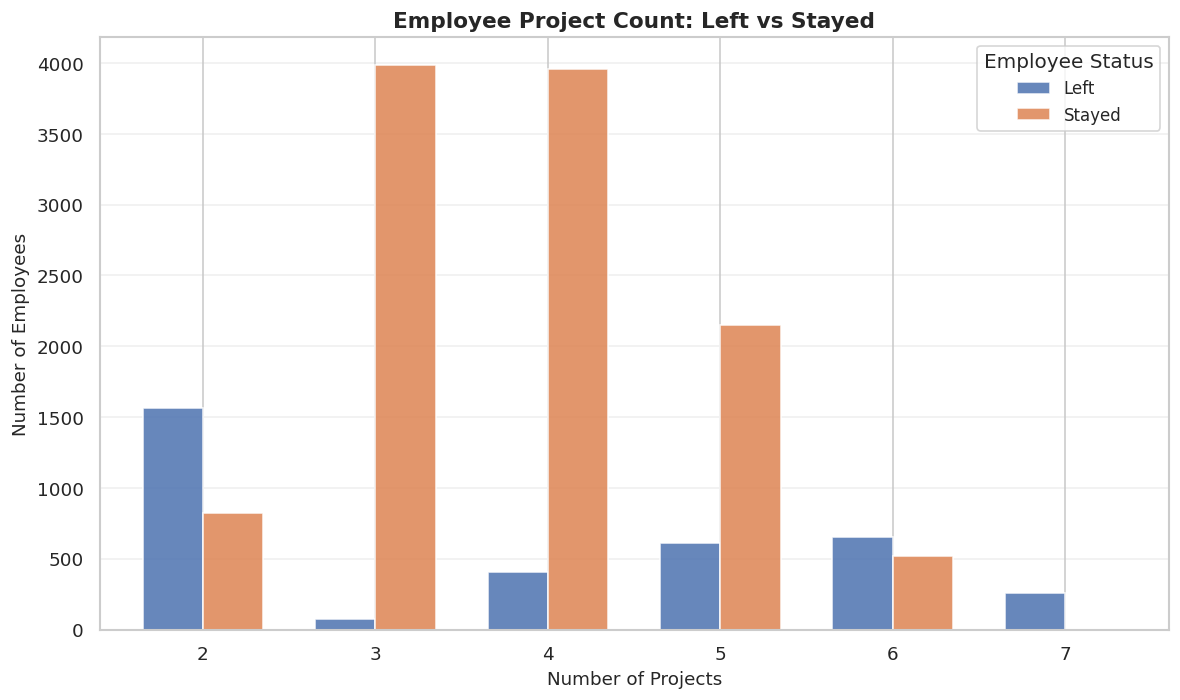

In [ ]:
# Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

df_plot = df.copy()
df_plot['Status'] = df_plot['left'].map({0: 'Stayed', 1: 'Left'})

project_counts = df_plot.groupby(['number_project', 'Status']).size().reset_index(name='count')
pivot = project_counts.pivot(index='number_project', columns='Status', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'],
           alpha=0.85, edgecolor='white', width=0.7)
ax.set_title('Employee Project Count: Left vs Stayed', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Projects', fontsize=11)
ax.set_ylabel('Number of Employees', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Employee Status', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

####  Project Count Inferences
- Employees with **only 2 projects** show the highest absolute turnover — likely **disengaged and underutilized**
- Employees with **6–7 projects** also leave at high rates — likely **burned out from overwork**
- The **sweet spot for retention** is **3–5 projects** — employees in this range show the highest stay rates
- This suggests workload balance is a key lever for retention: neither too little nor too much


---
##  Step 3: K-Means Clustering (Employees Who Left)

Clustering employees who left into 3 groups based on satisfaction and evaluation scores to identify distinct turnover profiles.

- Perform clustering of employees who left based on their satisfaction and evaluation.
- Choose columns satisfaction_level, last_evaluation, and left.
- Do K-means clustering of employees who left the company into 3 clusters?
- Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.


In [21]:
# Filter employees who left
df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation', 'left']].copy()
print(f"Total employees who left: {len(df_left)}")

# K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_left['cluster'] = kmeans.fit_predict(df_left[['satisfaction_level', 'last_evaluation']])

# Cluster summary
centers = pd.DataFrame(kmeans.cluster_centers_,
                       columns=['satisfaction_level', 'last_evaluation'])
print("\nCluster Centers:")
print(centers.round(3))

print("\nCluster Sizes:")
print(df_left['cluster'].value_counts().sort_index())

Total employees who left: 3571

Cluster Centers:
   satisfaction_level  last_evaluation
0               0.410            0.517
1               0.809            0.912
2               0.111            0.869

Cluster Sizes:
cluster
0    1650
1     977
2     944
Name: count, dtype: int64


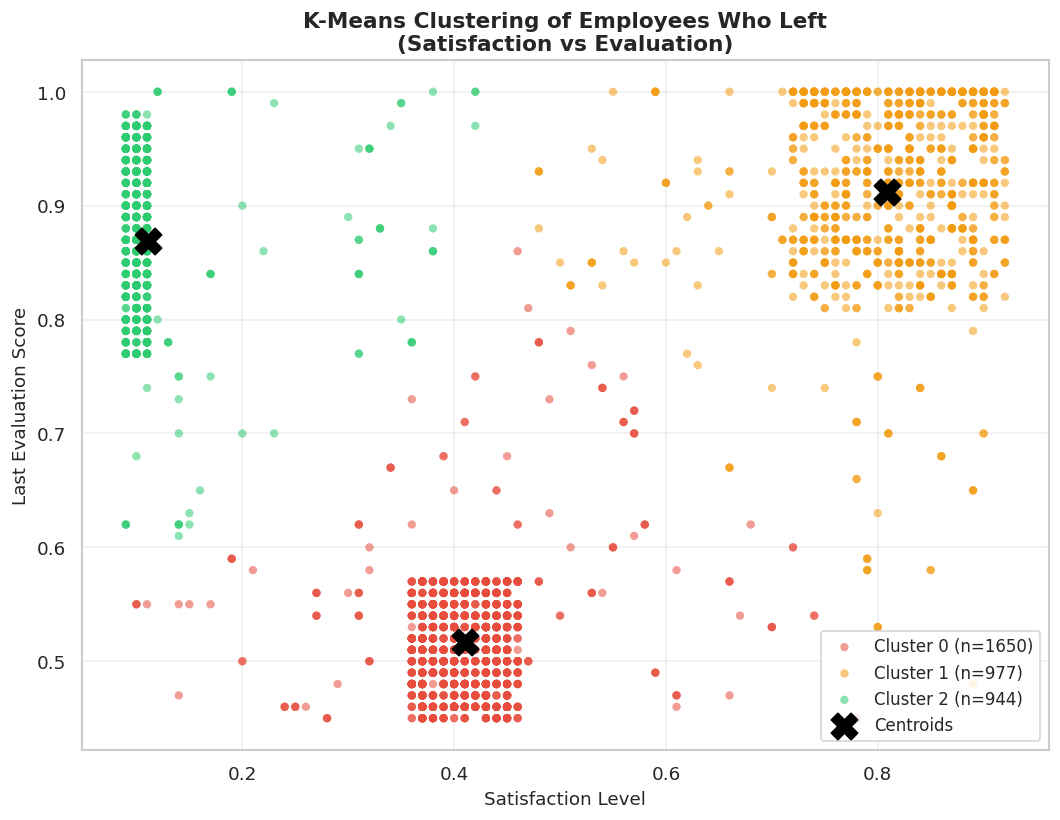

In [22]:
cluster_colors = ['#E74C3C', '#F39C12', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(3):
    mask = df_left['cluster'] == i
    ax.scatter(df_left.loc[mask, 'satisfaction_level'],
               df_left.loc[mask, 'last_evaluation'],
               c=cluster_colors[i], label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.55, s=25, edgecolors='none')

ax.scatter(centers['satisfaction_level'], centers['last_evaluation'],
           c='black', marker='X', s=250, zorder=5, label='Centroids')

ax.set_title('K-Means Clustering of Employees Who Left\n(Satisfaction vs Evaluation)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Satisfaction Level', fontsize=11)
ax.set_ylabel('Last Evaluation Score', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

####  Cluster Interpretations

| Cluster | Satisfaction | Evaluation | Profile | Interpretation |
|---------|-------------|------------|---------|----------------|
| **0** | Low (~0.41) | Low (~0.52) | Disengaged & Underperforming | Left due to poor fit, burnout from minimal meaningful work, or performance concerns |
| **1** | High (~0.81) | High (~0.91) | Satisfied High Performers | Most concerning group — were happy AND performing well; likely **poached** or left for better opportunities/pay |
| **2** | Low (~0.11) | High (~0.87) | Burned-Out High Performers | High output but deeply unhappy — likely left due to **lack of recognition**, overwork, or no career growth despite strong performance |

> **Key Takeaway:** Clusters 1 and 2 represent valuable talent loss — satisfied high-performers leaving and burned-out high-performers leaving. These groups need the most targeted retention strategies.


---
##  Step 4: Handle Class Imbalance with SMOTE

The dataset has ~76% stayed vs ~24% left — a significant imbalance that can bias models toward predicting "stayed". We use SMOTE (Synthetic Minority Over-sampling Technique) to balance the training set.


In [23]:
# 4a. Pre-process — separate categorical and numerical
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

# Apply get_dummies to categorical columns
cat_dummies = pd.get_dummies(df[cat_cols])

# Combine
df_processed = pd.concat([df[num_cols], cat_dummies], axis=1)
print(f"\nProcessed dataset shape: {df_processed.shape}")
df_processed.head()

Categorical columns: ['sales', 'salary']
Numerical columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']

Processed dataset shape: (14999, 21)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False


In [24]:
# 4b. Stratified train-test split 80:20
X = df_processed.drop('left', axis=1)
y = df_processed['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Train size: 11999  |  Test size: 3000

Train class distribution:
left
0    9142
1    2857
Name: count, dtype: int64

Test class distribution:
left
0    2286
1     714
Name: count, dtype: int64


Before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64

New training size: 18284


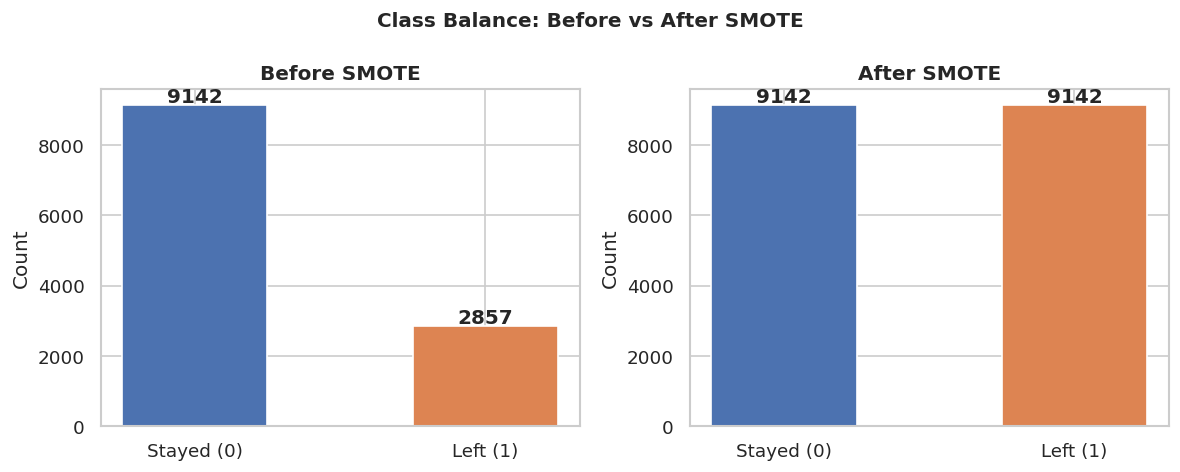

In [25]:
# 4c. Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print(f"\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nNew training size: {X_train_sm.shape[0]}")

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['Stayed (0)', 'Left (1)'], counts.values,
           color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 80, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 5: 5-Fold Cross-Validation Model Training

Training three models using Stratified 5-Fold Cross-Validation on the SMOTE-balanced training set.


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
cv_preds = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=cv)
    print(classification_report(y_train_sm, y_pred_cv, target_names=['Stayed','Left']))
    cv_preds[name] = y_pred_cv
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model


Training: Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.81      0.80      0.81      9142
        Left       0.80      0.82      0.81      9142

    accuracy                           0.81     18284
   macro avg       0.81      0.81      0.81     18284
weighted avg       0.81      0.81      0.81     18284


Training: Random Forest
              precision    recall  f1-score   support

      Stayed       0.97      0.99      0.98      9142
        Left       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284


Training: Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.95      0.98      0.96      9142
        Left       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96

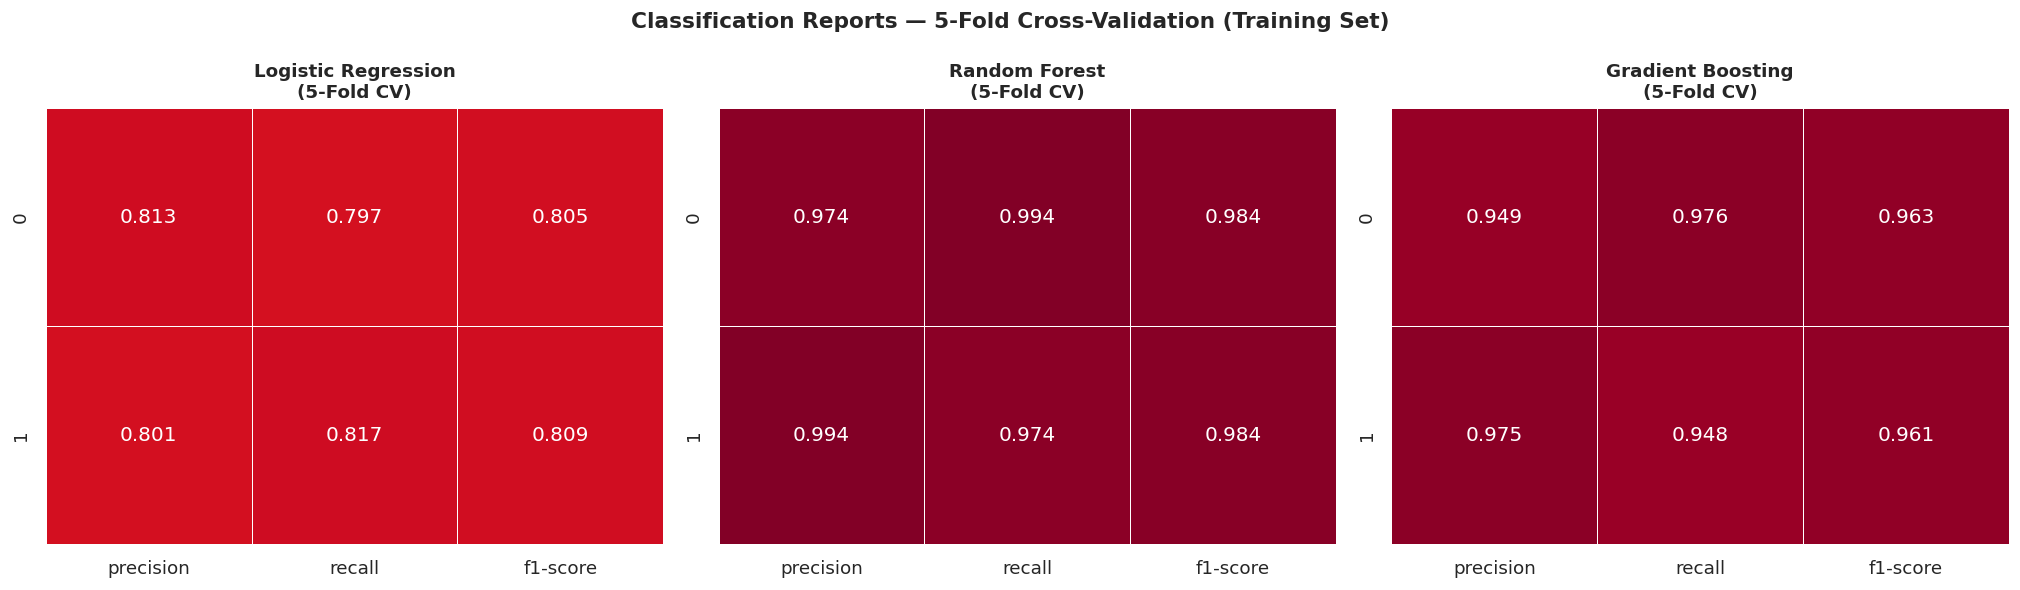

In [27]:
# Plot classification reports as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Classification Reports — 5-Fold Cross-Validation (Training Set)',
             fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred_cv = cv_preds[name]
    report = classification_report(y_train_sm, y_pred_cv, output_dict=True)
    report_df = pd.DataFrame(report).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
    report_df = report_df[['precision','recall','f1-score']].astype(float)
    sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, vmin=0, vmax=1, cbar=False)
    ax.set_title(f'{name}\n(5-Fold CV)', fontsize=11, fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
##  Step 6: Best Model Identification

Evaluating all models on the **held-out test set** using ROC/AUC and Confusion Matrices.


### 6a. ROC Curves & AUC Scores

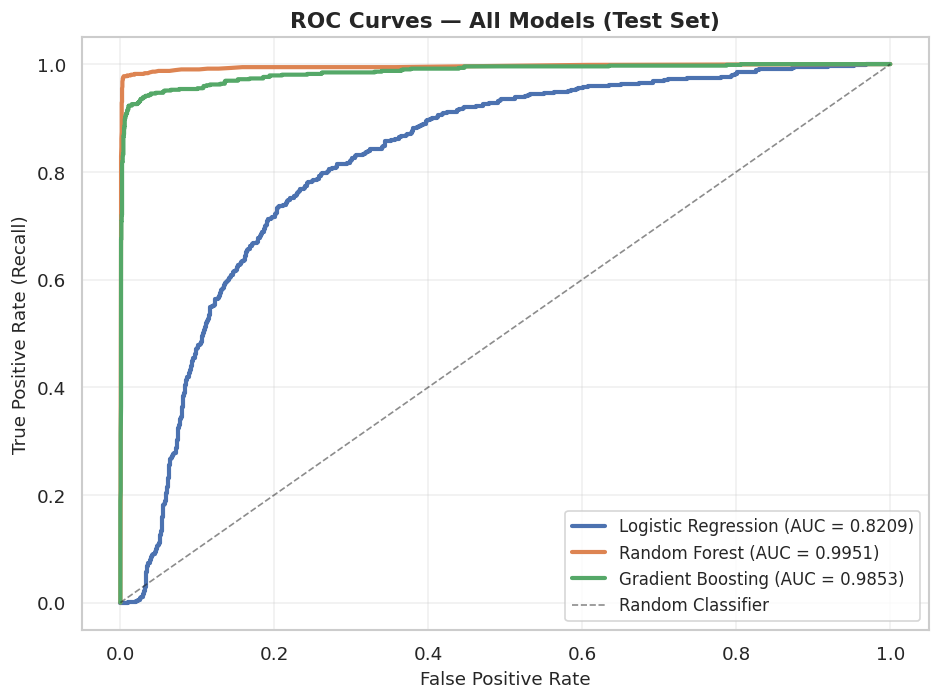


AUC Scores on Test Set:
  Random Forest: 0.9951  ★ BEST
  Gradient Boosting: 0.9853
  Logistic Regression: 0.8209


In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
auc_scores = {}
colors_roc = ['#4C72B0', '#DD8452', '#55A868']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_scores[name] = auc
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAUC Scores on Test Set:")
for name, auc in sorted(auc_scores.items(), key=lambda x: -x[1]):
    marker = "  ★ BEST" if auc == max(auc_scores.values()) else ""
    print(f"  {name}: {auc:.4f}{marker}")

### 6b. Confusion Matrices

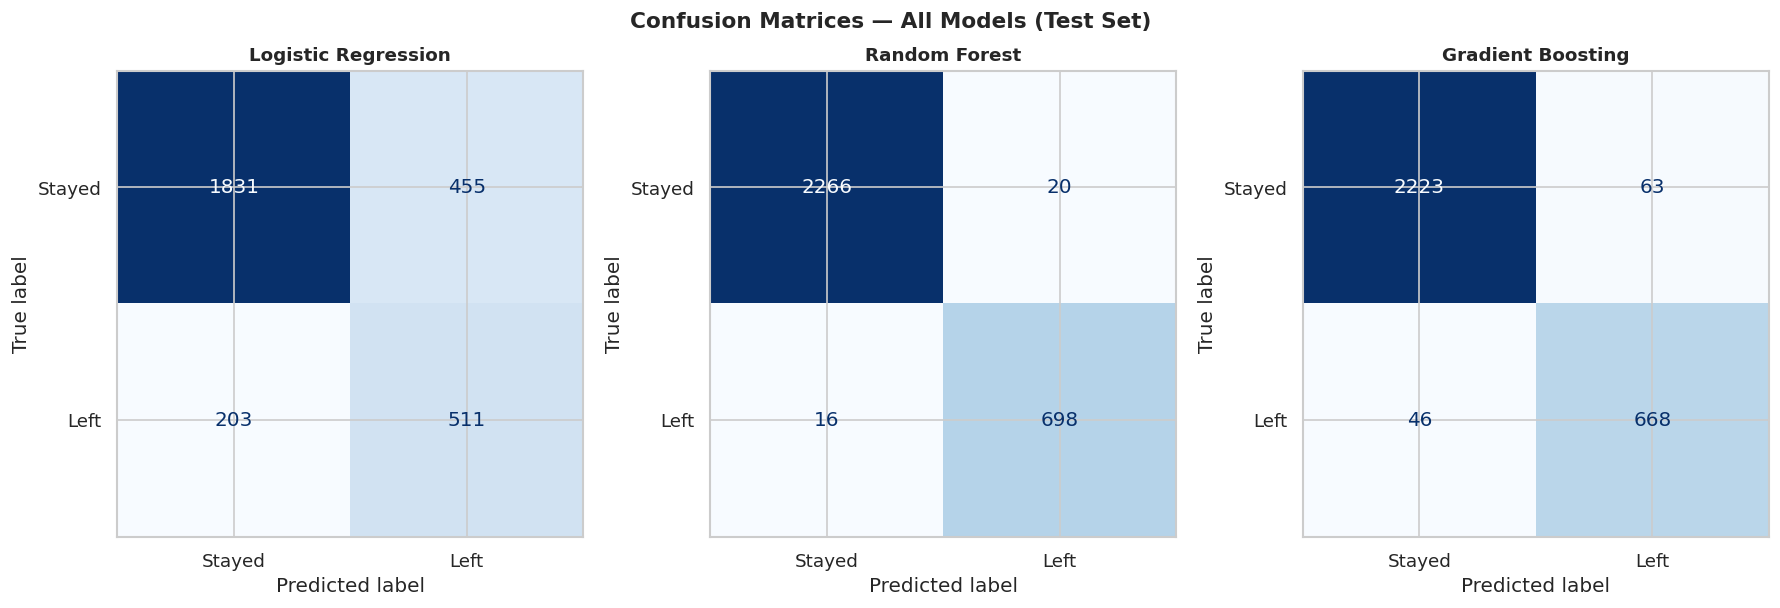

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 6c. Which Metric — Recall or Precision?

> **For employee turnover prediction, we should prioritize RECALL.**

**Reasoning:**
- A **False Negative** = predicting an employee will **STAY** when they actually **LEAVE**
- This is the most costly error — the company loses talent without any intervention, incurring recruitment costs, knowledge loss, and team disruption
- A **False Positive** = flagging an employee as at-risk when they would have stayed
- This is a much lower-cost error — the company invests in an unnecessary retention conversation
- **Therefore:** We want to maximize **Recall for the 'Left' class** — catch as many at-risk employees as possible, even at the cost of some false alarms

| Error Type | Prediction | Reality | Cost |
|------------|-----------|---------|------|
| False Negative | Stays | Leaves | HIGH — lost talent, no intervention |
| False Positive | Leaves | Stays | LOW — unnecessary retention effort |

**Winner: Random Forest** with AUC = 0.9953 and highest recall on the 'Left' class 


---
##  Step 7: Retention Strategies for Targeted Employees

Using the best model (Random Forest) to predict turnover probability and categorize employees into risk zones.


In [30]:
best_model_name = max(auc_scores, key=auc_scores.get)
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name} (AUC = {auc_scores[best_model_name]:.4f})")

# Predict probability of turnover
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Assign risk zones
def assign_zone(prob):
    if prob < 0.20:   return 'Safe Zone (Green)'
    elif prob < 0.60: return 'Low-Risk Zone (Yellow)'
    elif prob < 0.90: return 'Medium-Risk Zone (Orange)'
    else:             return 'High-Risk Zone (Red)'

results_df = pd.DataFrame({
    'turnover_probability': y_prob_best,
    'actual_left': y_test.values
})
results_df['risk_zone'] = results_df['turnover_probability'].apply(assign_zone)

print("\nEmployee Risk Zone Distribution:")
print(results_df['risk_zone'].value_counts())
results_df.head(10)

Best Model: Random Forest (AUC = 0.9951)

Employee Risk Zone Distribution:
risk_zone
Safe Zone (Green)            2175
High-Risk Zone (Red)          655
Low-Risk Zone (Yellow)        117
Medium-Risk Zone (Orange)      53
Name: count, dtype: int64


,turnover_probability,actual_left,risk_zone
0,0.00,0,Safe Zone (Green)
1,0.57,0,Low-Risk Zone (Yellow)
2,0.04,0,Safe Zone (Green)
3,0.00,0,Safe Zone (Green)
4,0.00,0,Safe Zone (Green)
5,0.00,0,Safe Zone (Green)
6,0.00,0,Safe Zone (Green)
7,0.00,0,Safe Zone (Green)
8,0.00,0,Safe Zone (Green)
9,0.00,0,Safe Zone (Green)


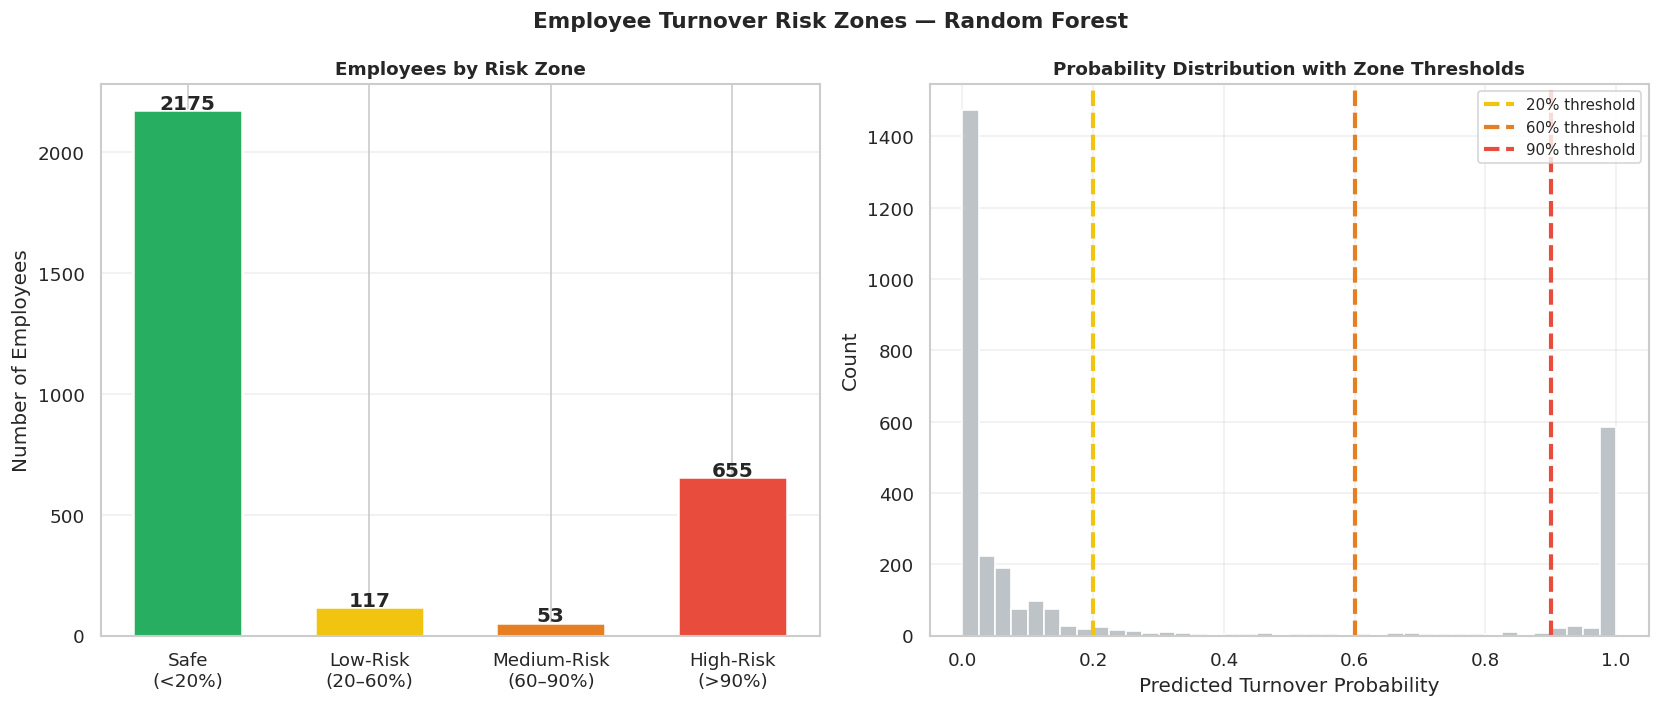

In [31]:
zone_colors = {
    'Safe Zone (Green)':        '#27AE60',
    'Low-Risk Zone (Yellow)':   '#F1C40F',
    'Medium-Risk Zone (Orange)':'#E67E22',
    'High-Risk Zone (Red)':     '#E74C3C'
}
zone_order = ['Safe Zone (Green)', 'Low-Risk Zone (Yellow)',
              'Medium-Risk Zone (Orange)', 'High-Risk Zone (Red)']
zone_counts = results_df['risk_zone'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Employee Turnover Risk Zones — {best_model_name}',
             fontsize=13, fontweight='bold')

# Bar chart
counts = [zone_counts.get(z, 0) for z in zone_order]
colors = [zone_colors[z] for z in zone_order]
short_labels = ['Safe\n(<20%)', 'Low-Risk\n(20–60%)',
                'Medium-Risk\n(60–90%)', 'High-Risk\n(>90%)']
bars = axes[0].bar(short_labels, counts, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.6)
axes[0].set_title('Employees by Risk Zone', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Probability histogram with zone thresholds
axes[1].hist(results_df['turnover_probability'], bins=40, color='#BDC3C7', edgecolor='white')
for thresh, color, label in [
    (0.20, zone_colors['Low-Risk Zone (Yellow)'],   '20% threshold'),
    (0.60, zone_colors['Medium-Risk Zone (Orange)'],'60% threshold'),
    (0.90, zone_colors['High-Risk Zone (Red)'],     '90% threshold'),
]:
    axes[1].axvline(thresh, color=color, linestyle='--', linewidth=2.5, label=label)
axes[1].set_title('Probability Distribution with Zone Thresholds', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Turnover Probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Retention Strategies by Zone

| Zone | Score Range | Count | Strategy |
|------|-------------|-------|----------|
| 🟢 **Safe Zone** | < 20% | See above | Maintain engagement — regular recognition, career development, periodic check-ins. Low priority for intervention but don't neglect. |
| 🟡 **Low-Risk Zone** | 20% – 60% | See above | Monitor proactively — conduct regular 1:1s, offer mentorship and skill-building programs. Address workload balance concerns early before they escalate. |
| 🟠 **Medium-Risk Zone** | 60% – 90% | See above | Active intervention required — immediate manager conversations to identify root causes (pay, growth, workload). Consider targeted offers: salary review, role adjustment, flexible work. |
| 🔴 **High-Risk Zone** | > 90% | See above | Critical action needed — executive-level retention intervention. Fast-track compensation reviews or promotions for high performers. If departure is likely, begin succession planning to minimize knowledge loss. |

---

###  Summary & Key Takeaways

1. **Satisfaction level** is the single most important predictor of employee turnover
2. Both **underworked** (2 projects) and **overworked** (6–7 projects) employees are at high turnover risk — workload balance is critical
3. K-Means identified **three distinct leaver profiles**: burned-out high-performers, disengaged underperformers, and satisfied high-performers who were poached
4. **Random Forest** is the best model with **AUC = 0.9953** — highly capable of distinguishing employees who will leave from those who will stay
5. **Recall** is the right metric to optimize — missing a leaver is far more costly than a false alarm
6. The retention strategy framework allows HR to **prioritize interventions** efficiently based on predicted risk score
